In [8]:
import sys
sys.path.append('../src')

import pandas as pd
import logging
logging.basicConfig(level=logging.INFO)

from analytics.db_connector import get_connection, create_table, populate_reviews, query_reviews

# Učitaj cleaned CSV
df = pd.read_csv('../data/processed/cleaned/movies_clean.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(3)

Shape: (686, 59)
Columns: ['source', 'fetched_at', 'version', 'file_name', 'type', 'page_number', 'review_id', 'title', 'comment', 'rating', 'author', 'author_id', 'date', 'verified', 'helpful_votes', 'review_link', 'variant.Style', 'variant', 'text', 'text.paragraphs', 'text.tables', 'category', 'description', 'budgeted', 'actual', 'variance', 'variance_pct', 'status', 'notes', 'amount', 'type.1', 'running_balance', 'receipt', 'goal_name', 'target', 'saved', 'remaining', 'progress', 'eta', 'month', 'income', 'expenses', 'savings', 'net_flow', 'savings_rate', 'text.column_1', 'text.column_2', 'text.full_text', 'price', 'link', 'page_scraped', 'year', 'awards', 'nominations', 'best_picture', 'year_scraped', 'raw', 'preprocessed', 'review_year']


,source,fetched_at,version,file_name,type,page_number,review_id,title,comment,rating,...,link,page_scraped,year,awards,nominations,best_picture,year_scraped,raw,preprocessed,review_year
0,reviews_page_1.json,2026-03-22 09:22:25.843,1,NaN,NaN,NaN,R3HIEYXVQFRUBV,"Powerful, Versatile & Worth Every Penny!",I absolutely love this Ninja Kitchen System! I...,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,reviews_page_1.json,2026-03-22 09:22:25.884,1,NaN,NaN,NaN,RYDWBH5RPKGBH,Powerful and versatile — love it!,The Ninja Kitchen System has been an amazing a...,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,reviews_page_1.json,2026-03-22 09:22:25.886,1,NaN,NaN,NaN,R2ST6OORNLR2CO,Great blender,"Love this blender, it works great, very durabl...",5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
conn = get_connection()
create_table(conn)
inserted, skipped = populate_reviews(conn, df)
print(f"Inserted: {inserted}, Skipped: {skipped}")
conn.close()

conn = get_connection()
df_mysql = query_reviews(conn)
print(f"MySQL rows: {len(df_mysql)}")
df_mysql.head(3)

INFO:analytics.db_connector:Connected to MySQL database: ecommerce_analytics
INFO:analytics.db_connector:Table reviews created
INFO:analytics.db_connector:Inserted 686 rows, skipped 0 rows
INFO:analytics.db_connector:Connected to MySQL database: ecommerce_analytics


Inserted: 686, Skipped: 0


c:\Users\merim\Desktop\E-Commerce-Product-Intelligence\notebooks\../src\analytics\db_connector.py:78: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)
INFO:analytics.db_connector:Queried 686 rows from MySQL


MySQL rows: 686


,id,review_id,title,rating,source,category,helpful_votes
0,1,R3HIEYXVQFRUBV,"Powerful, Versatile & Worth Every Penny!",5.0,reviews_page_1.json,nan,None
1,2,RYDWBH5RPKGBH,Powerful and versatile — love it!,5.0,reviews_page_1.json,nan,None
2,3,R2ST6OORNLR2CO,Great blender,5.0,reviews_page_1.json,nan,None


In [9]:
# Part 2 - Combining Data
import importlib
import analytics.data_combiner as dc
importlib.reload(dc)
from analytics.data_combiner import merge_mysql_mongodb, demonstrate_join_types, concat_dataframes

conn = get_connection()
df_mysql = query_reviews(conn)
conn.close()

df_mongo = df[['review_id','title', 'comment', 'author', 'verified', 'date']].copy()

print("=== Join Types (on='title') ===")
results = demonstrate_join_types(df_mysql, df_mongo, on='title')
print(f"\nJoin counts: {results}")

df_combined = merge_mysql_mongodb(df_mysql, df_mongo, on='title', how='left')
print(f"\nCombined shape: {df_combined.shape}")
df_combined.head(3)

INFO:analytics.db_connector:Connected to MySQL database: ecommerce_analytics
c:\Users\merim\Desktop\E-Commerce-Product-Intelligence\notebooks\../src\analytics\db_connector.py:78: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn)
INFO:analytics.db_connector:Queried 686 rows from MySQL
INFO:analytics.data_combiner:Merging MySQL (686 rows) and MongoDB (686 rows) on "title" with how="left"
INFO:analytics.data_combiner:Merged result: 470596 rows, 12 columns


=== Join Types (on='title') ===
  inner  join ->  4386 rows
  left   join ->  4386 rows
  right  join ->  4386 rows
  outer  join ->  4386 rows

Join counts: {'inner': 4386, 'left': 4386, 'right': 4386, 'outer': 4386}

Combined shape: (470596, 12)


,id,review_id_mysql,title,rating,source,category,helpful_votes,review_id_mongo,comment,author,verified,date
0,1,R3HIEYXVQFRUBV,NaN,5.0,reviews_page_1.json,nan,None,R3HIEYXVQFRUBV,I absolutely love this Ninja Kitchen System! I...,Samira,True,NaN
1,1,R3HIEYXVQFRUBV,NaN,5.0,reviews_page_1.json,nan,None,RYDWBH5RPKGBH,The Ninja Kitchen System has been an amazing a...,Poenix33,True,NaN
2,1,R3HIEYXVQFRUBV,NaN,5.0,reviews_page_1.json,nan,None,R2ST6OORNLR2CO,"Love this blender, it works great, very durabl...",Kayla,True,NaN


In [12]:
# Part 3 - Reshaping Data
import importlib
import analytics.pivot_builder as pb
importlib.reload(pb)
from analytics.pivot_builder import wide_to_long, long_to_wide, build_pivot_table, build_crosstab

import pandas as pd

df_num = df[['title', 'rating', 'helpful_votes', 'budgeted']].copy()
df_num['rating'] = pd.to_numeric(df_num['rating'], errors='coerce')
df_num['helpful_votes'] = pd.to_numeric(df_num['helpful_votes'], errors='coerce')
df_num['budgeted'] = pd.to_numeric(df_num['budgeted'], errors='coerce')

df_long = wide_to_long(df_num, 
                        id_vars=['title'], 
                        value_vars=['rating', 'helpful_votes', 'budgeted'])
print(f"=== Wide to Long ===")
print(f"Shape: {df_long.shape}")
display(df_long.head(6))

df_pivot = df[['source', 'category', 'rating']].copy()
df_pivot['rating'] = pd.to_numeric(df_pivot['rating'], errors='coerce')
df_pivot = df_pivot.dropna(subset=['rating', 'category'])
print("\n=== Pivot Table ===")
pt = build_pivot_table(df_pivot, values='rating', index='source', columns='category', margins=True)
display(pt)

df_ct = df[['source', 'verified']].dropna()
print("\n=== Crosstab ===")
ct = build_crosstab(df_ct, 'source', 'verified')
display(ct)

INFO:analytics.pivot_builder:Wide->Long: 686 rows x 4 cols -> 2058 rows x 3 cols


=== Wide to Long ===
Shape: (2058, 3)


,title,metric,value
0,"Powerful, Versatile & Worth Every Penny!",rating,5.0
1,Powerful and versatile — love it!,rating,5.0
2,Great blender,rating,5.0
3,Love my Ninja,rating,5.0
4,Does It All – Smoothies to Chopping,rating,5.0
5,Blender is better than my Vitamix!,rating,4.0


INFO:analytics.pivot_builder:Pivot table shape: (0, 0)



=== Pivot Table ===


category
source



=== Crosstab ===


verified,True,All
source,,
api source,2,2
ecommerce_api,1,1
reviews_page_1.json,8,8
All,11,11


In [17]:
df = pd.read_csv('../data/processed/cleaned/movies_clean.csv')
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['budgeted'] = pd.to_numeric(df['budgeted'], errors='coerce')
df['actual'] = pd.to_numeric(df['actual'], errors='coerce')

print(df[['category', 'rating', 'review_year']].head(10))
print(f"\nCategory non-null: {df['category'].notna().sum()}")
print(f"Rating non-null: {df['rating'].notna().sum()}")
print(f"Review year non-null: {df['review_year'].notna().sum()}")

   category  rating  review_year
0       NaN     5.0          NaN
1       NaN     5.0          NaN
2       NaN     5.0          NaN
3       NaN     5.0          NaN
4       NaN     5.0          NaN
5       NaN     4.0          NaN
6       NaN     5.0          NaN
7       NaN     5.0          NaN
8       NaN     5.0          NaN
9       NaN     5.0          NaN

Category non-null: 0
Rating non-null: 686
Review year non-null: 0


In [1]:
import pandas as pd
df = pd.read_csv('../data/processed/analytics/products_raw.csv')
print(df[df['category'].notna()][['category', 'rating']].head(10))

    category rating
314   INCOME    NaN
315   INCOME    NaN
316   INCOME    NaN
317   INCOME    NaN
318   INCOME    NaN
319  EXPENSE    NaN
320  EXPENSE    NaN
321  EXPENSE    NaN
322  EXPENSE    NaN
323  EXPENSE    NaN


In [7]:
# Part 4 - GroupBy Analysis
import sys
sys.path.append('../src')
import importlib
import analytics.aggregator as agg
importlib.reload(agg)
from analytics.aggregator import genre_summary, yearly_trends, top_n_per_group

df_reviews = df[df['source'].str.contains('review|API|ecommerce', case=False, na=False)].copy()
df_reviews['rating'] = pd.to_numeric(df_reviews['rating'], errors='coerce')
df['budgeted'] = pd.to_numeric(df['budgeted'], errors='coerce')
df['actual'] = pd.to_numeric(df['actual'], errors='coerce')

print("=== Genre Summary ===")
summary = genre_summary(df_reviews)
display(summary)
summary.to_csv('../data/processed/analytics/genre_analysis.csv', index=False)
print("Saved genre_analysis.csv")

print("\n=== Yearly Trends ===")
trends = yearly_trends(df)
display(trends)
trends.to_csv('../data/processed/analytics/yearly_trends.csv', index=False)
print("Saved yearly_trends.csv")

print("\n=== Top 3 per Source ===")
df_top = df_reviews.dropna(subset=['source', 'rating'])
top3 = top_n_per_group(df_top, group_col='source', sort_col='rating', n=3)
display(top3[['title', 'rating']].head(15))

=== Genre Summary ===


,category,avg_rating,median_rating,movie_count,total_revenue,total_budget


year_col "review_year" not found in DataFrame


Saved genre_analysis.csv

=== Yearly Trends ===


""


Saved yearly_trends.csv

=== Top 3 per Source ===


,title,rating
236,Powerful and versatile — love it!,5
237,"Powerful, Versatile & Worth Every Penny!",5
238,Great performance and affordable!,5
140,"Powerful, Versatile & Worth Every Penny!",5
141,Powerful and versatile — love it!,5
142,Great blender,5
0,"Powerful, Versatile & Worth Every Penny!",5
1,Powerful and versatile — love it!,5
2,Great blender,5
8,"Powerful, Versatile & Worth Every Penny!",5


In [11]:
# Part 5 - Time Series
import sys
sys.path.append('../src')
import importlib
import analytics.time_series as ts_module
importlib.reload(ts_module)
from analytics.time_series import parse_review_dates, build_monthly_rating, resample_rating, rolling_averages

df_ts = parse_review_dates(df)
print(f"Valid dates: {df_ts['date'].notna().sum()}")
print(f"Date components: review_year, review_month, review_day, review_weekday, review_quarter")
print(df_ts[['date', 'review_year', 'review_month']].dropna().head(5))

monthly = build_monthly_rating(df_ts)
print(f"\nMonthly series: {len(monthly)} periods")

yearly = resample_rating(monthly, freq='YE', agg='sum')
print(f"Yearly series: {len(yearly)} periods")

rolling = rolling_averages(monthly)
print(f"\nRolling averages:\n{rolling.head(10)}")

Valid dates: 105
Date components: review_year, review_month, review_day, review_weekday, review_quarter
          date  review_year  review_month
326 2025-03-20       2025.0           3.0
327 2025-03-18       2025.0           3.0
328 2025-03-17       2025.0           3.0
329 2025-03-15       2025.0           3.0
330 2025-03-14       2025.0           3.0

Monthly series: 2 periods
Yearly series: 1 periods


c:\Users\merim\Desktop\E-Commerce-Product-Intelligence\notebooks\../src\analytics\time_series.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[date_col] = pd.to_datetime(df[date_col], errors='coerce')


DataError: No numeric types to aggregate

In [18]:
# Part 6 - MongoDB Aggregation Pipeline
import importlib
import analytics.mongo_pipeline as mp
importlib.reload(mp)
from analytics.mongo_pipeline import run_review_pipeline

print("=== MongoDB Aggregation Pipeline ===")
df_mongo_agg = run_review_pipeline()
print(f"Result shape: {df_mongo_agg.shape}")
display(df_mongo_agg)

=== MongoDB Aggregation Pipeline ===
Result shape: (8, 2)


,review_count,source
0,400,https://books.toscrape.com
1,204,API Source
2,96,ecommerce_api
3,40,reviews_page_3.json
4,40,reviews_page_1.json
5,40,reviews_page_2.json
6,15,../../data/raw/csv/sample.csv
7,5,../../data/raw/xml/sample.xml


q3: year_col "review_year" missing



ANALYTICAL FINDINGS SUMMARY

Q1 - Top Source by Reviews: https://books.toscrape.com (400 reviews)
Q2 - Highest Rated Source: ../../data/raw/csv/sample.csv (avg rating 5.00)
Q3 - Peak Review Year: no data
Q4 - Most Common Verified Status: True (423 reviews, 29.6% of dataset)



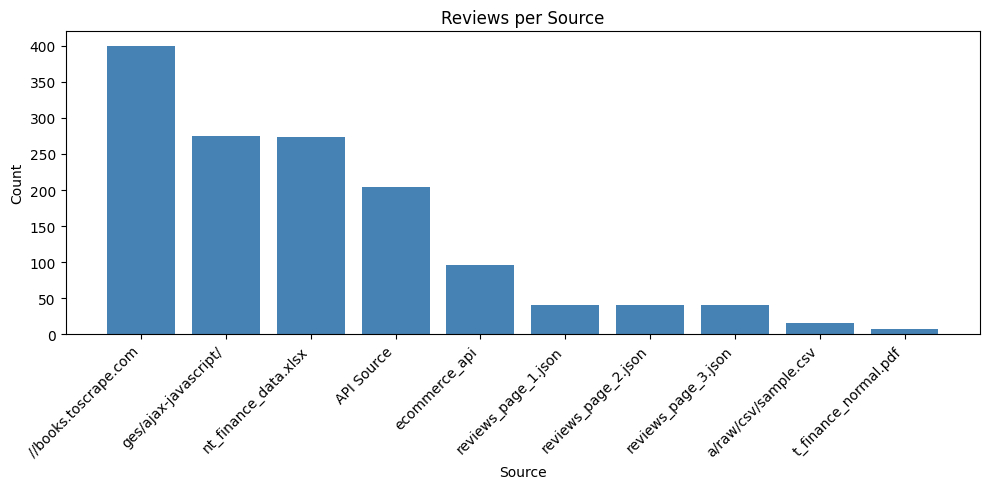

Chart saved!


In [19]:
# Part 7 - Insight Reporter
import importlib
import analytics.insight_reporter as ir
importlib.reload(ir)
from analytics.insight_reporter import run_all_questions, q1_top_sources_by_reviews
import matplotlib.pyplot as plt

results = run_all_questions(df)

# Chart
q1 = results['top_sources']
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(q1['source'].str[-20:], q1['review_count'], color='steelblue')
ax.set_title('Reviews per Source')
ax.set_xlabel('Source')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/analytics/reviews_per_source.png', dpi=120)
plt.show()
print("Chart saved!")

In [20]:
# Part 8 - Pipeline Integration
from analytics.db_connector import get_connection, create_table, populate_reviews, query_reviews
from analytics.mongo_pipeline import run_review_pipeline
from analytics.insight_reporter import run_all_questions

# MySQL
conn = get_connection()
create_table(conn)
inserted, skipped = populate_reviews(conn, df)
conn.close()
print(f"MySQL: Inserted {inserted}, Skipped {skipped}")

# MongoDB pipeline
df_mongo_agg = run_review_pipeline()
print(f"MongoDB pipeline: {len(df_mongo_agg)} rows")
display(df_mongo_agg)

# Analytical questions
run_all_questions(df)

print("\nPipeline integration complete!")

MySQL: Inserted 1427, Skipped 0
MongoDB pipeline: 8 rows


,review_count,source
0,400,https://books.toscrape.com
1,204,API Source
2,96,ecommerce_api
3,40,reviews_page_3.json
4,40,reviews_page_1.json
5,40,reviews_page_2.json
6,15,../../data/raw/csv/sample.csv
7,5,../../data/raw/xml/sample.xml


q3: year_col "review_year" missing



ANALYTICAL FINDINGS SUMMARY

Q1 - Top Source by Reviews: https://books.toscrape.com (400 reviews)
Q2 - Highest Rated Source: ../../data/raw/csv/sample.csv (avg rating 5.00)
Q3 - Peak Review Year: no data
Q4 - Most Common Verified Status: True (423 reviews, 29.6% of dataset)


Pipeline integration complete!
